<a href="https://colab.research.google.com/github/Villager12755/Invasive-Species-Modeling-through-Random-Forest-and-Logistic-Regression/blob/main/Predicting_Invasive_Species_Spread_in_Texas_With_Machine_Learning_Random_Forest_%26_Logistic_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Texas Chinese Tallow invasion risk model – data is downloaded from the internet if needed.
Using existing /content/data/raw/chinese_tallow_occurrences.csv
Using existing /content/data/raw/texas_counties.geojson
Using existing /content/data/processed/texas_chinese_tallow_county_features.csv

--- Observation map (where the species has been seen) ---


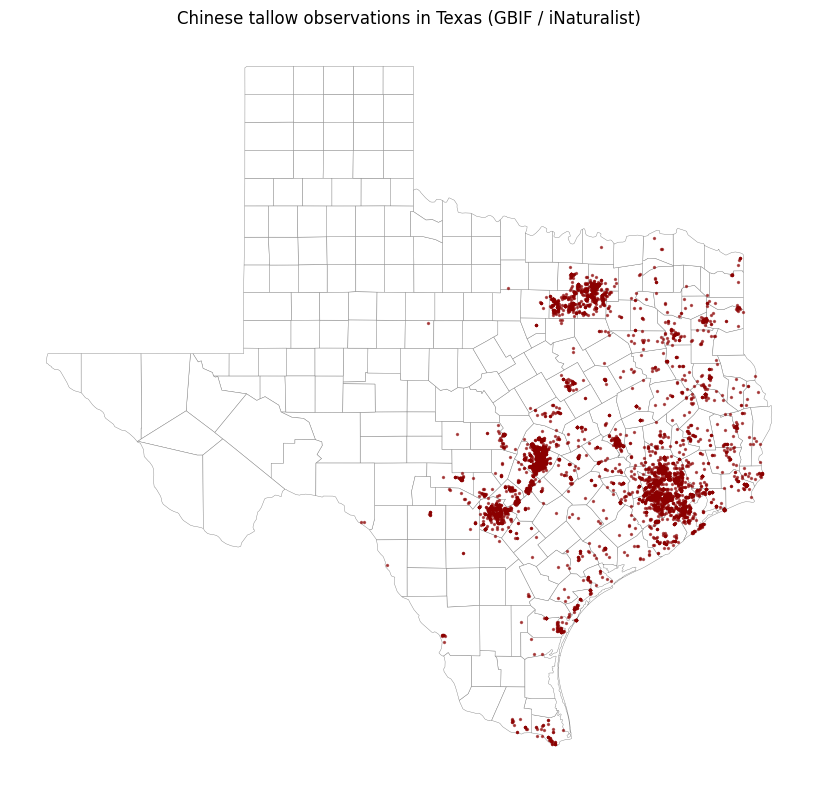


--- Risk heatmap (predicted invasion risk by county) ---
Logistic regression accuracy: 0.84375
Logistic regression ROC AUC: 0.8985221674876848
Random forest accuracy: 0.828125
Random forest ROC AUC: 0.9182266009852217
Feature importance: {'centroid_lat': np.float64(0.29100514240530745), 'centroid_lon': np.float64(0.5207497492236337), 'log_area_km2': np.float64(0.1882451083710588)}
Saved risk table to /content/data/processed/texas_chinese_tallow_county_risk.csv


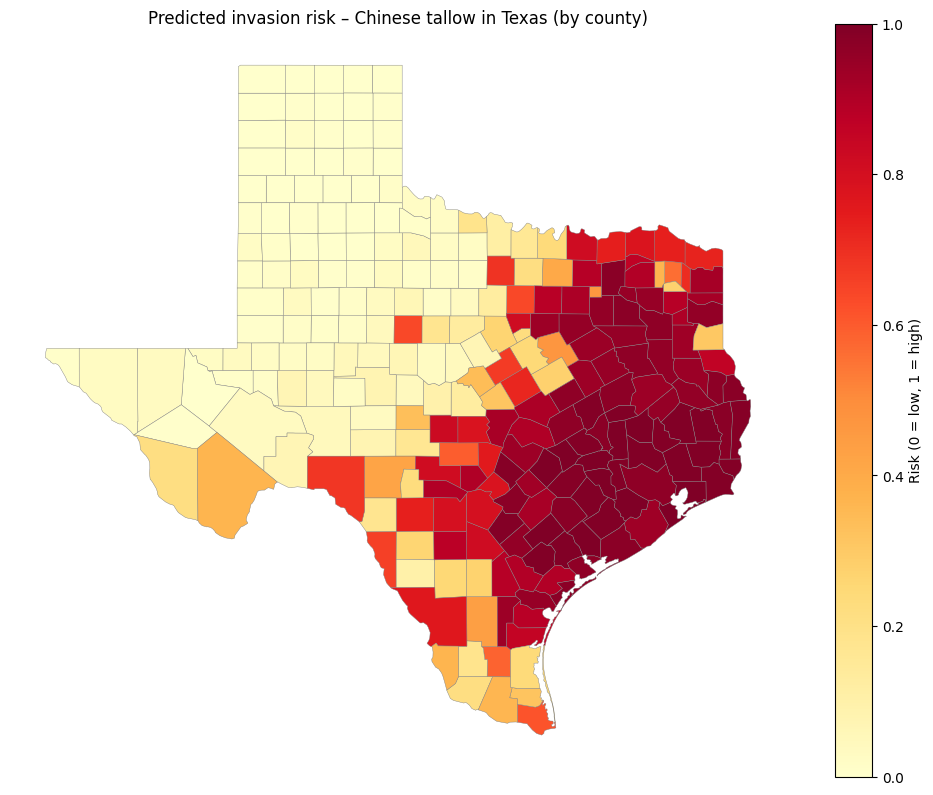

Saved heatmap to /content/reports/chinese_tallow_risk_heatmap.png
Done.


In [ ]:
import os
import sys
import subprocess

try:
    import google.colab
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "geopandas", "matplotlib", "scikit-learn", "requests", "numpy"])
except ImportError:
    pass

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

if "__file__" in dir():
    PROJECT_ROOT = os.path.dirname(os.path.abspath(__file__))
else:
    PROJECT_ROOT = os.getcwd()
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")

OCCURRENCE_PATH = os.path.join(RAW_DIR, "chinese_tallow_occurrences.csv")
COUNTIES_PATH = os.path.join(RAW_DIR, "texas_counties.geojson")
FEATURES_PATH = os.path.join(PROCESSED_DIR, "texas_chinese_tallow_county_features.csv")
RISK_PATH = os.path.join(PROCESSED_DIR, "texas_chinese_tallow_county_risk.csv")
HEATMAP_PATH = os.path.join(REPORTS_DIR, "chinese_tallow_risk_heatmap.png")

GBIF_URL = "https://api.gbif.org/v1/occurrence/search"
TAXON_KEY = 3054399
LIMIT_PER_PAGE = 300
MAX_RECORDS = 6000
COUNTIES_GEOJSON_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"


def download_occurrences():
    os.makedirs(RAW_DIR, exist_ok=True)
    all_rows = []
    offset = 0
    while True:
        r = requests.get(
            GBIF_URL,
            params={
                "taxonKey": TAXON_KEY,
                "country": "US",
                "stateProvince": "Texas",
                "hasCoordinate": "true",
                "limit": LIMIT_PER_PAGE,
                "offset": offset,
            },
            timeout=30,
        )
        r.raise_for_status()
        data = r.json()
        results = data.get("results", [])
        if not results:
            break
        for rec in results:
            gadm = rec.get("gadm") or {}
            county = (gadm.get("level2") or {}).get("name", "")
            if rec.get("decimalLatitude") is None or rec.get("decimalLongitude") is None:
                continue
            all_rows.append({
                "gbifID": rec.get("key"),
                "decimalLatitude": rec.get("decimalLatitude"),
                "decimalLongitude": rec.get("decimalLongitude"),
                "year": rec.get("year"),
                "county": county,
            })
        offset += len(results)
        print("Fetched", len(all_rows), "occurrences...")
        if data.get("endOfRecords", True) or len(results) < LIMIT_PER_PAGE:
            break
        if len(all_rows) >= MAX_RECORDS:
            all_rows = all_rows[:MAX_RECORDS]
            break
    df = pd.DataFrame(all_rows)
    df.to_csv(OCCURRENCE_PATH, index=False)
    print("Saved", len(df), "records to", OCCURRENCE_PATH)
    return df


def download_counties():
    os.makedirs(RAW_DIR, exist_ok=True)
    gdf = gpd.read_file(COUNTIES_GEOJSON_URL)
    gdf["id"] = gdf["id"].astype(str).str.zfill(5)
    gdf["STATEFP"] = gdf["id"].str[:2]
    texas = gdf[gdf["STATEFP"] == "48"].copy()
    texas = texas.rename(columns={"id": "FIPS"})
    texas.to_file(COUNTIES_PATH, driver="GeoJSON")
    print("Saved", len(texas), "Texas counties to", COUNTIES_PATH)
    return texas


def build_features():
    occ = pd.read_csv(OCCURRENCE_PATH)
    occ = occ.dropna(subset=["decimalLatitude", "decimalLongitude", "year"])
    occ["year"] = occ["year"].astype(int)
    occ = occ[(occ["year"] >= 2000) & (occ["year"] <= 2030)]
    occ["county_clean"] = occ["county"].astype(str).str.strip().str.title()

    missing = (occ["county_clean"].isna() | (occ["county_clean"] == "") |
              (occ["county_clean"].str.lower() == "nan"))
    if missing.any():
        counties_gdf = gpd.read_file(COUNTIES_PATH).to_crs("EPSG:4326")
        idx = occ.index[missing]
        pts = gpd.GeoDataFrame(
            {"gbifID": occ.loc[idx, "gbifID"]},
            geometry=gpd.points_from_xy(
                occ.loc[idx, "decimalLongitude"],
                occ.loc[idx, "decimalLatitude"],
            ),
            crs="EPSG:4326",
        )
        joined = gpd.sjoin(
            pts[["gbifID", "geometry"]],
            counties_gdf[["NAME", "geometry"]],
            predicate="within",
            how="left",
        )
        name_map = joined.set_index("gbifID")["NAME"].to_dict()
        occ.loc[idx, "county_clean"] = occ.loc[idx, "gbifID"].map(name_map)
        occ = occ[occ["county_clean"].notna() & (occ["county_clean"] != "")]
    occ["county_clean"] = occ["county_clean"].astype(str)

    agg = occ.groupby("county_clean").agg(
        sighting_count=("gbifID", "count"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    ).reset_index()
    agg["presence"] = 1
    agg = agg.rename(columns={"county_clean": "NAME"})

    gdf = gpd.read_file(COUNTIES_PATH).to_crs("EPSG:4326")
    centroids = gdf.geometry.to_crs("EPSG:3857").centroid.to_crs("EPSG:4326")
    gdf["centroid_lon"] = centroids.x
    gdf["centroid_lat"] = centroids.y
    gdf["area_km2"] = gdf.geometry.to_crs("EPSG:3857").area / 1e6
    gdf["log_area_km2"] = np.log1p(gdf["area_km2"])
    counties = gdf[["NAME", "FIPS", "centroid_lat", "centroid_lon", "CENSUSAREA", "area_km2", "log_area_km2"]].copy()

    features = counties.merge(agg, on="NAME", how="left")
    features["presence"] = features["presence"].fillna(0).astype(int)
    features["sighting_count"] = features["sighting_count"].fillna(0).astype(int)
    features["log_sighting_count"] = np.log1p(features["sighting_count"])
    if "geometry" in features.columns:
        features = features.drop(columns=["geometry"])

    os.makedirs(PROCESSED_DIR, exist_ok=True)
    features.to_csv(FEATURES_PATH, index=False)
    print("Saved", len(features), "counties to", FEATURES_PATH)
    return features


def train_and_heatmap():
    df = pd.read_csv(FEATURES_PATH)
    counties_gdf = gpd.read_file(COUNTIES_PATH)

    feature_cols = ["centroid_lat", "centroid_lon", "log_area_km2"]
    X = df[feature_cols].values
    y = df["presence"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_train, y_train)
    y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
    y_pred_lr = (y_prob_lr >= 0.5).astype(int)
    print("Logistic regression accuracy:", accuracy_score(y_test, y_pred_lr))
    print("Logistic regression ROC AUC:", roc_auc_score(y_test, y_prob_lr))

    rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
    rf.fit(X_train, y_train)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]
    y_pred_rf = (y_prob_rf >= 0.5).astype(int)
    print("Random forest accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Random forest ROC AUC:", roc_auc_score(y_test, y_prob_rf))
    print("Feature importance:", dict(zip(feature_cols, rf.feature_importances_)))

    df["risk_score"] = rf.predict_proba(X)[:, 1]
    mn, mx = df["risk_score"].min(), df["risk_score"].max()
    df["risk_score_norm"] = (df["risk_score"] - mn) / (mx - mn) if mx > mn else 0.0

    df.to_csv(RISK_PATH, index=False)
    print("Saved risk table to", RISK_PATH)

    df_ = df.copy()
    df_["FIPS"] = df_["FIPS"].astype(str).str.zfill(5)
    counties_ = counties_gdf.copy()
    counties_["FIPS"] = counties_["FIPS"].astype(str).str.zfill(5)
    merged = counties_.merge(df_[["FIPS", "risk_score_norm"]], on="FIPS", how="left")
    merged["risk_score_norm"] = merged["risk_score_norm"].fillna(0.0)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    merged.plot(column="risk_score_norm", cmap="YlOrRd", linewidth=0.3, edgecolor="gray", legend=True, ax=ax, legend_kwds={"label": "Risk (0 = low, 1 = high)"})
    ax.set_axis_off()
    ax.set_title("Predicted invasion risk – Chinese tallow in Texas (by county)", fontsize=12)
    plt.tight_layout()
    os.makedirs(REPORTS_DIR, exist_ok=True)
    plt.savefig(HEATMAP_PATH, dpi=200)
    plt.show()
    plt.close()
    print("Saved heatmap to", HEATMAP_PATH)


def show_observation_map():
    occ = pd.read_csv(OCCURRENCE_PATH)
    counties_gdf = gpd.read_file(COUNTIES_PATH).to_crs("EPSG:4326")
    pts = gpd.GeoDataFrame(
        occ,
        geometry=gpd.points_from_xy(occ["decimalLongitude"], occ["decimalLatitude"]),
        crs="EPSG:4326",
    )
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    counties_gdf.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.3)
    pts.plot(ax=ax, markersize=2, color="darkred", alpha=0.6)
    ax.set_axis_off()
    ax.set_title("Chinese tallow observations in Texas (GBIF / iNaturalist)", fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()


def main():
    print("Texas Chinese Tallow invasion risk model – data is downloaded from the internet if needed.")
    if not os.path.exists(OCCURRENCE_PATH):
        print("Downloading occurrence data from GBIF...")
        download_occurrences()
    else:
        print("Using existing", OCCURRENCE_PATH)

    if not os.path.exists(COUNTIES_PATH):
        print("Downloading Texas county boundaries...")
        download_counties()
    else:
        print("Using existing", COUNTIES_PATH)

    if not os.path.exists(FEATURES_PATH):
        build_features()
    else:
        print("Using existing", FEATURES_PATH)

    print("\n--- Observation map (where the species has been seen) ---")
    show_observation_map()

    print("\n--- Risk heatmap (predicted invasion risk by county) ---")
    train_and_heatmap()
    print("Done.")


if __name__ == "__main__":
    main()
